<a href="https://colab.research.google.com/github/rupakdey94/EV-Adoption-Analysis/blob/main/Welcome_To_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

COVID19_Healthcare_Analytics


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
from sklearn.impute import SimpleImputer

pd.set_option('display.max_columns',None)

In [2]:
df = pd.read_csv("COVID19_line_list_data.csv")

In [3]:
df.head()

df.tail()

df.sample(10)

df.shape

df.columns

df.info()

df.describe(include='all')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1085 entries, 0 to 1084
Data columns (total 27 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     1085 non-null   int64  
 1   case_in_country        888 non-null    float64
 2   reporting date         1084 non-null   object 
 3   Unnamed: 3             0 non-null      float64
 4   summary                1080 non-null   object 
 5   location               1085 non-null   object 
 6   country                1085 non-null   object 
 7   gender                 902 non-null    object 
 8   age                    843 non-null    float64
 9   symptom_onset          563 non-null    object 
 10  If_onset_approximated  560 non-null    float64
 11  hosp_visit_date        507 non-null    object 
 12  exposure_start         128 non-null    object 
 13  exposure_end           341 non-null    object 
 14  visiting Wuhan         1085 non-null   int64  
 15  from

,id,case_in_country,reporting date,Unnamed: 3,summary,location,country,gender,age,symptom_onset,If_onset_approximated,hosp_visit_date,exposure_start,exposure_end,visiting Wuhan,from Wuhan,death,recovered,symptom,source,link,Unnamed: 21,Unnamed: 22,Unnamed: 23,Unnamed: 24,Unnamed: 25,Unnamed: 26
count,1085.000000,888.000000,1084,0.0,1080,1085,1085,902,843.000000,563,560.000000,507,128,341,1085.000000,1081.000000,1085,1085,270,1085,1085,0.0,0.0,0.0,0.0,0.0,0.0
unique,NaN,NaN,43,NaN,967,156,38,2,NaN,70,NaN,60,39,52,NaN,NaN,14,32,108,85,490,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,2/27/2020,NaN,new confirmed COVID-19 patient in South Korea:,South Korea,China,male,NaN,1/23/2020,NaN,1/23/2020,1/26/2020,1/22/2020,NaN,NaN,0,0,fever,Ministry of Health,https://www.mhlw.go.jp/stf/houdou/houdou_list_...,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,91,NaN,22,112,197,520,NaN,27,NaN,34,14,34,NaN,NaN,1022,926,73,179,88,NaN,NaN,NaN,NaN,NaN,NaN
mean,543.000000,48.841216,NaN,NaN,NaN,NaN,NaN,NaN,49.483689,NaN,0.042857,NaN,NaN,NaN,0.176959,0.144311,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,313.356825,78.853528,NaN,NaN,NaN,NaN,NaN,NaN,18.255334,NaN,0.202716,NaN,NaN,NaN,0.381810,0.351567,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,1.000000,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,0.250000,NaN,0.000000,NaN,NaN,NaN,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,272.000000,11.000000,NaN,NaN,NaN,NaN,NaN,NaN,35.000000,NaN,0.000000,NaN,NaN,NaN,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,543.000000,28.000000,NaN,NaN,NaN,NaN,NaN,NaN,51.000000,NaN,0.000000,NaN,NaN,NaN,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,814.000000,67.250000,NaN,NaN,NaN,NaN,NaN,NaN,64.000000,NaN,0.000000,NaN,NaN,NaN,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

df.head()

,id,case_in_country,reporting date,summary,location,country,gender,age,symptom_onset,If_onset_approximated,hosp_visit_date,exposure_start,exposure_end,visiting Wuhan,from Wuhan,death,recovered,symptom,source,link
0,1,NaN,1/20/2020,First confirmed imported COVID-19 pneumonia pa...,"Shenzhen, Guangdong",China,male,66.0,01/03/20,0.0,01/11/20,12/29/2019,01/04/20,1,0.0,0,0,NaN,Shenzhen Municipal Health Commission,http://wjw.sz.gov.cn/wzx/202001/t20200120_1898...
1,2,NaN,1/20/2020,First confirmed imported COVID-19 pneumonia pa...,Shanghai,China,female,56.0,1/15/2020,0.0,1/15/2020,NaN,01/12/20,0,1.0,0,0,NaN,Official Weibo of Shanghai Municipal Health Co...,https://www.weibo.com/2372649470/IqogQhgfa?fro...
2,3,NaN,1/21/2020,First confirmed imported cases in Zhejiang: pa...,Zhejiang,China,male,46.0,01/04/20,0.0,1/17/2020,NaN,01/03/20,0,1.0,0,0,NaN,Health Commission of Zhejiang Province,http://www.zjwjw.gov.cn/art/2020/1/21/art_1202...
3,4,NaN,1/21/2020,new confirmed imported COVID-19 pneumonia in T...,Tianjin,China,female,60.0,NaN,NaN,1/19/2020,NaN,NaN,1,0.0,0,0,NaN,人民日报官方微博,https://m.weibo.cn/status/4463235401268457?
4,5,NaN,1/21/2020,new confirmed imported COVID-19 pneumonia in T...,Tianjin,China,male,58.0,NaN,NaN,1/14/2020,NaN,NaN,0,0.0,0,0,NaN,人民日报官方微博,https://m.weibo.cn/status/4463235401268457?


In [5]:
missing = df.isnull().sum()

missing.sort_values(ascending=False)

,0
exposure_start,957
symptom,815
exposure_end,744
hosp_visit_date,578
If_onset_approximated,525
symptom_onset,522
age,242
case_in_country,197
gender,183
summary,5


In [6]:
df.drop_duplicates(inplace=True)

In [7]:
df.dtypes

,0
id,int64
case_in_country,float64
reporting date,object
summary,object
location,object
country,object
gender,object
age,float64
symptom_onset,object
If_onset_approximated,float64


In [8]:
date_columns = [
    "reporting date",
    "symptom_onset",
    "hosp_visit_date",
    "exposure_start",
    "exposure_end"
]

for col in date_columns:
    df[col] = pd.to_datetime(df[col], errors="coerce")


/tmp/ipykernel_831/3581612953.py:10: UserWarning:

Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.

/tmp/ipykernel_831/3581612953.py:10: UserWarning:

Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.

/tmp/ipykernel_831/3581612953.py:10: UserWarning:

Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.



In [9]:
df["age"].unique()

array([66.  , 56.  , 46.  , 60.  , 58.  , 44.  , 34.  , 37.  , 39.  ,
       18.  , 32.  , 51.  , 57.  , 50.  , 52.  , 33.  , 40.  , 70.  ,
         nan, 28.  , 19.  , 29.  , 55.  , 68.  , 38.  , 72.  , 45.  ,
       42.  , 69.  , 63.  , 62.  , 49.  , 48.  , 36.  , 61.  , 89.  ,
       75.  , 82.  , 81.  , 65.  , 80.  , 53.  , 86.  , 84.  , 59.  ,
       23.  , 43.  , 22.  , 47.  , 85.  , 73.  , 30.  , 76.  , 79.  ,
       87.  , 78.  , 67.  ,  2.  , 20.  , 24.  , 41.  ,  9.  , 27.  ,
       15.  , 21.  , 64.  , 71.  , 31.  , 35.  ,  4.  , 25.  ,  5.  ,
       11.  , 83.  ,  0.5 , 54.  , 26.  ,  1.  , 77.  , 74.  ,  6.  ,
        8.  , 16.  ,  0.25, 91.  , 96.  ])

In [10]:
df["age"] = pd.to_numeric(df["age"], errors="coerce")

In [11]:
from sklearn.impute import SimpleImputer

pd.set_option('display.max_columns',None)

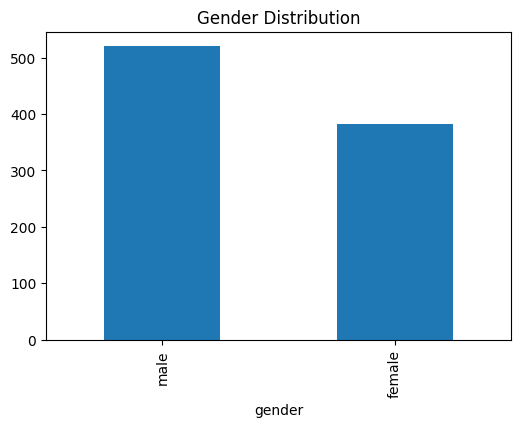

In [12]:
df["gender"].value_counts().plot(
    kind="bar",
    figsize=(6,4)
)

plt.title("Gender Distribution")
plt.show()

In [13]:
country_cases = df["country"].value_counts()

country_cases.head(20)

,count
country,
China,197
Japan,190
South Korea,114
Hong Kong,94
Singapore,93
Germany,54
Thailand,41
France,39
Taiwan,34


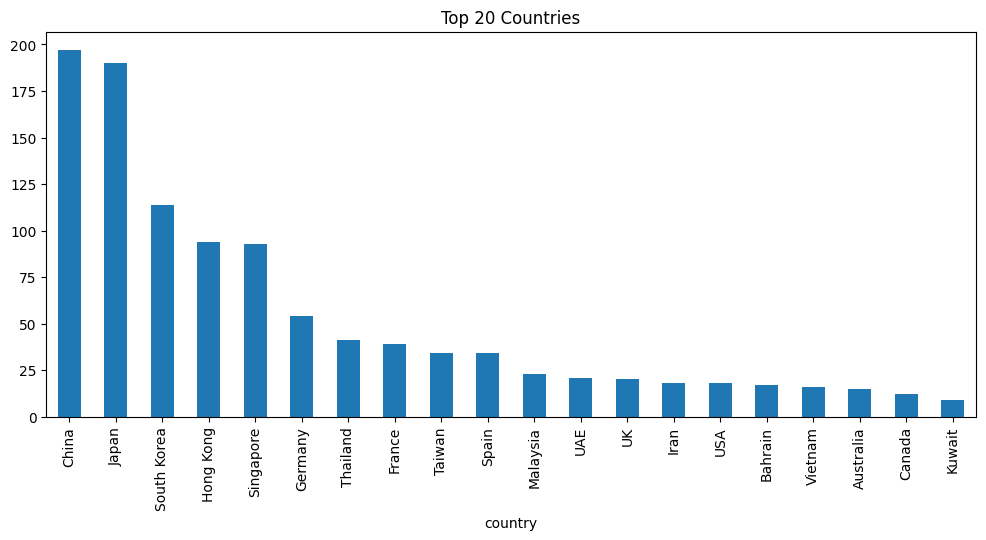

In [14]:
country_cases.head(20).plot(
    kind="bar",
    figsize=(12,5)
)

plt.title("Top 20 Countries")
plt.show()

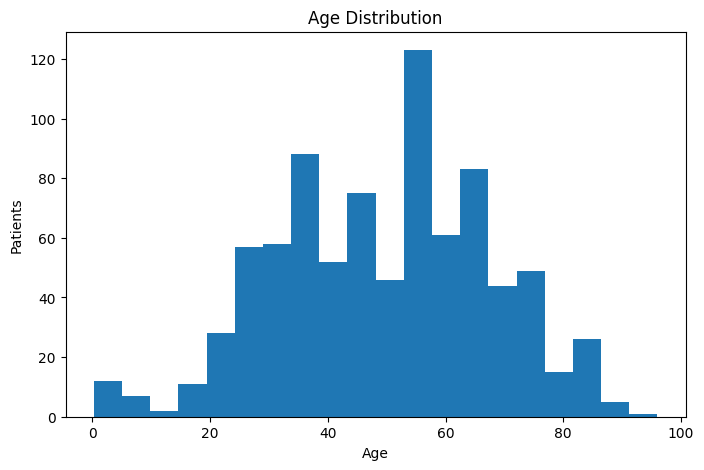

In [15]:
plt.figure(figsize=(8,5))

plt.hist(df["age"], bins=20)

plt.title("Age Distribution")

plt.xlabel("Age")

plt.ylabel("Patients")

plt.show()

In [16]:
df["death"].value_counts()

,count
death,
0,1022
1,42
2/23/2020,4
2/26/2020,3
2/27/2020,2
2/25/2020,2
2/19/2020,2
2/21/2020,2
2/14/2020,1


In [17]:
death_rate = (df["death"].notna().sum()/len(df))*100

print(death_rate)

100.0


In [18]:
df["recovered"].value_counts()

,count
recovered,
0,926
2/18/2020,13
2/19/2020,13
12/30/1899,12
02/12/20,11
2/21/2020,10
2/20/2020,9
2/15/2020,9
2/14/2020,8


In [19]:
recovery_rate = (df["recovered"].notna().sum()/len(df))*100

print(recovery_rate)

100.0


In [20]:
df["symptom"].value_counts().head(15)

,count
symptom,
fever,73
"fever, cough",36
cough,14
"fever, malaise",7
"fever, cough, malaise",6
"fever, sore throat",6
"fever, cough, sputum",3
"cough, fever",3
"fever, runny nose",3


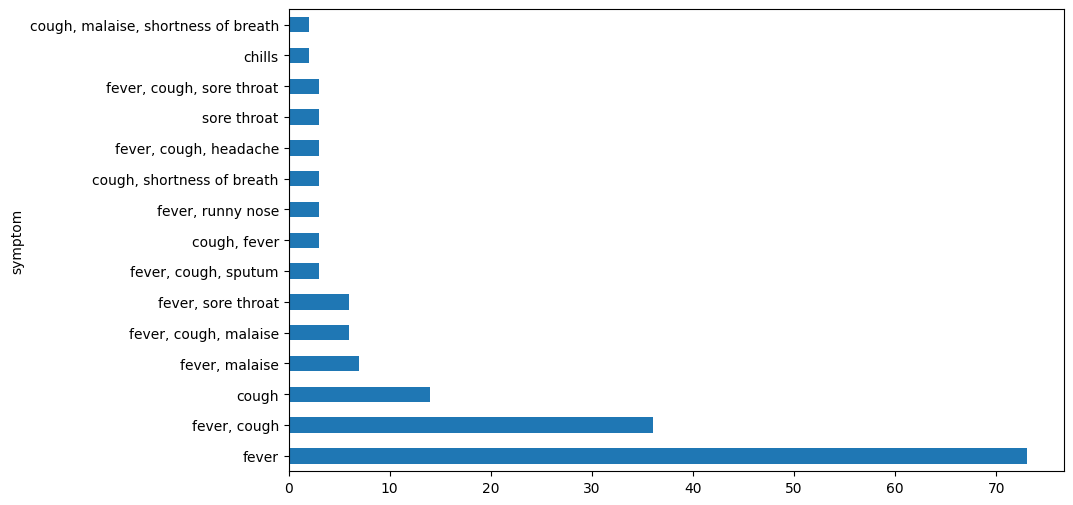

In [21]:
df["symptom"].value_counts().head(15).plot(
    kind="barh",
    figsize=(10,6)
)

plt.show()

In [22]:
daily = df.groupby("reporting date").size().reset_index(name="Cases")

In [23]:
recovery_country = df.groupby("country")["recovered"].count()

recovery_country.sort_values(ascending=False)

,recovered
country,
China,197
Japan,190
South Korea,114
Hong Kong,94
Singapore,93
Germany,54
Thailand,41
France,39
Spain,34


In [24]:
top = df.groupby("country").size()

top.sort_values(ascending=False).head(20)

,0
country,
China,197
Japan,190
South Korea,114
Hong Kong,94
Singapore,93
Germany,54
Thailand,41
France,39
Spain,34


In [25]:
df["Waiting_Days"] = (
    df["hosp_visit_date"] -
    df["symptom_onset"]
).dt.days

In [26]:
df["Waiting_Days"].mean()

np.float64(2.7616926503340755)

In [28]:
df.to_csv(
    "COVID19_Cleaned.csv",
    index=False
)